# What a refocusing pulse fixes, and what it does not

[`01_build.ipynb`](01_build.ipynb) placed a 180 in the middle of an EPI and asserted that `k` is
exact at every echo. Two questions are left, and only a simulation answers either.

| | |
|---|---|
| **1. is it a spin echo at all?** | the one claim arithmetic cannot make: the train recovers the phantom's **T2**, and the same acquisition without the 180 recovers **T2\*** |
| **2. does it fix the distortion?** | **no**, and this is the section the notebook exists for. Most readers expect the other answer |
| **3. what it does fix** | the decay *across the train*, and therefore the point spread along `ky` |
| **4. partial echo** | a shorter window is a shorter lobe is less distortion — and POCS puts the missing half back |
| **5. segmentation** | a shorter train is the only thing that touches the distortion, and `S` interleaved shots buy one without unfolding anything |

## The one sentence

> A refocusing pulse refocuses at **one instant**. It recovers the phase that static field offsets
> accumulated *up to* the echo, and it does nothing at all to the phase that accumulates
> **between** echoes — which is where an EPI's distortion comes from.

So the spin echo and the gradient echo distort **identically**, at the same echo spacing, and the
EPI-specific artefacts measured in
[`../gre_epi_2d/02`](../gre_epi_2d/02_simulate_and_reconstruct.ipynb) are all still here. What
changes is the *envelope* over the train, and §3 measures that.

Same rules as that notebook: every **number** is measured on one spin, every ghost is quoted
against its own `B0 = 0` control, and the sequences are the `.seq` files [`01`](01_build.ipynb)
wrote, read back through MRzero's own parser.

**Needs `seqcraft[sim,recon]`** plus `pygrappa`, and the BrainWeb phantom
[`../gre_2d/02`](../gre_2d/02_simulate_and_reconstruct.ipynb) downloads into `examples/data/`.

In [1]:
import os

SIM_THREADS = 4
for _var in ('OMP_NUM_THREADS', 'MKL_NUM_THREADS', 'RAYON_NUM_THREADS',
             'OPENBLAS_NUM_THREADS', 'NUMEXPR_NUM_THREADS'):
    os.environ[_var] = str(SIM_THREADS)

import sys
import tempfile
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import MRzeroCore as mr0
import numpy as np
import pypulseq as pp
import torch
from scipy.interpolate import CubicSpline

import seqcraft as sc

sys.path.insert(0, str(Path('..').resolve()))
import phantom as ph            # noqa: E402 -- the shared BrainWeb preparation, one directory up

torch.set_num_threads(SIM_THREADS)
plt.rcParams['figure.dpi'] = 66

#: Reconstruct the BrainWeb slab in sections 4 and 5.  Every *number* outside them is measured on
#: one spin.
BRAIN_IMAGES = True
NZ = 2
#: The same slab as ../gre_epi_2d/02 and as every other example, so the two notebooks' images
#: compare directly -- which is what section 2 is measured against.
Z_CENTER = 64
N_COILS = 8

SEQ_DIR = Path('seq')
nominal = np.load(SEQ_DIR / 'se_epi_2d_nominal.npz')

MATRIX = tuple(int(v) for v in nominal['matrix'])
FOV_MM = tuple(float(v) for v in nominal['fov_mm'])
THICKNESS_MM = float(nominal['thickness_mm'])
CENTER_LINE = int(nominal['center_line'])
NX, NY = MATRIX
DK_X, DK_Y = 1e3 / FOV_MM[0], 1e3 / FOV_MM[1]
LINES = [int(v) for v in nominal['lines']]
DWELL_S = float(nominal['dwell_s'])
OVERSAMPLING = int(nominal['oversampling'])
TE_S = float(nominal['te_s'])
SHOTS = [int(v) for v in nominal['shots']]

opts = pp.Opts(
    max_grad=40, grad_unit='mT/m',
    max_slew=180, slew_unit='T/m/s',
    B0=3.0,
    rf_dead_time=100e-6,
    rf_ringdown_time=30e-6,
    adc_dead_time=10e-6,
)
grad_raster = sc.Raster(opts.grad_raster_time)


def readout(**kwargs):
    """The readout `01` built.  `EPI2D` ships, so this is an import rather than a copy."""
    return sc.modules.EPI2D(opts=opts, fov_mm=FOV_MM, matrix=MATRIX, dwell_s=DWELL_S,
                            oversampling=OVERSAMPLING, prephase=False, **kwargs)


epi = readout()
epi_pf = readout(partial_fourier=0.75)
esp = epi.echo_spacing_s
assert np.allclose(epi.k_read_per_m, nominal['k_read_per_m'], atol=1e-9)

exc = sc.modules.Excitation(opts=opts, flip_deg=90.0, thickness_mm=THICKNESS_MM,
                            duration_s=float(nominal['excite_duration_s']))
refoc = sc.modules.Refocusing(
    opts=opts, thickness_mm=THICKNESS_MM * float(nominal['refocus_factor']),
    duration_s=float(nominal['refocus_duration_s']),
    crush_cycles_per_voxel=float(nominal['crush_cycles_slice']), crush_voxel_mm=THICKNESS_MM)

print(f'the same readout as ../gre_epi_2d: {epi.num_samples} samples, '
      f'{esp * 1e6:.0f} us echo spacing, {epi.bandwidth_hz_px:.0f} Hz/px')
print(f'TE {TE_S * 1e3:.3f} ms, spin echo {float(nominal["spin_echo_s"]) * 1e3:.3f} ms, '
      f'train {NY * esp * 1e3:.2f} ms')
print(f'partial echo: {epi_pf.num_samples} samples, '
      f'{float(nominal["echo_spacing_s_pf"]) * 1e6:.0f} us echo spacing, TE '
      f'{float(nominal["te_s_pf"]) * 1e3:.2f} ms')
print()
print(f'{torch.get_num_threads()} simulation threads of {os.cpu_count()} cores.')
print(f'Budget: ~50 s of one-voxel measurement, and BRAIN_IMAGES = {BRAIN_IMAGES}'
      f'{" -- about 4 minutes of brain on top" if BRAIN_IMAGES else " -- no brain"}.')

D:\MIniconda\envs\NUM\Lib\site-packages\cupy\_environment.py:215: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(


D:\MIniconda\envs\NUM\Lib\site-packages\sigpy\config.py:27: UserWarning: Importing cupy.cuda.cudnn failed. For more details, see the error stack below:
DLL load failed while importing cudnn: The specified module could not be found.
  warnings.warn(


the same readout as ../gre_epi_2d: 256 samples, 700 us echo spacing, 1562 Hz/px
TE 100.001 ms, spin echo 100.000 ms, train 89.60 ms
partial echo: 192 samples, 540 us echo spacing, TE 100.00 ms

4 simulation threads of 32 cores.
Budget: ~50 s of one-voxel measurement, and BRAIN_IMAGES = True -- about 4 minutes of brain on top.


---
## 1. Is it a spin echo?

The claim arithmetic cannot make. A probe with **no encoding at all** — one 90, one 180 at half
the echo time, an ADC straddling where the echo should be — swept over TE. With the 180 the
envelope decays at **T2**; without it, at **T2\***, which for this phantom is
`1/T2 + 1/T2' = 1/(80 ms) + 1/(50 ms)`.

This is [`../se_2d/02`](../se_2d/02_simulate_and_reconstruct.ipynb)'s measurement, repeated here
because the thing being asserted is that the *EPI* version of the placement is still a spin echo.

In [2]:
def spin(*, t1_s=1.0, t2_s=0.080, t2dash_s=0.050, offset_hz=0.0, b1=1.0):
    """One spin at isocentre.  Floats, not numpy scalars -- see ../se_2d/02 for why."""
    built = mr0.CustomVoxelPhantom(
        pos=[[0.0, 0.0, 0.0]], PD=[1.0], T1=[float(t1_s)], T2=[float(t2_s)],
        T2dash=[float(t2dash_s)], D=[0.0],
        voxel_size=FOV_MM[0] / NX / 1e3, voxel_shape='box').build()
    built.B0 = built.B0.float() * 0 + float(offset_hz)
    built.B1 = built.B1.float() * 0 + float(b1)
    return built


def run(tree, phantom, *, name='probe', states=200):
    """Compile a tree, write it, import the file, simulate.  Never simulate the tree."""
    with tempfile.TemporaryDirectory(prefix='se-epi-') as scratch:
        path = Path(scratch) / f'{name}.seq'
        with warnings.catch_warnings():
            warnings.simplefilter('ignore', sc.SeqCraftWarning)
            sc.compile(tree, opts, name=name).write(str(path))
        imported = mr0.Sequence.import_file(str(path))
        graph = mr0.compute_graph(imported, phantom, max_state_count=states, min_state_mag=1e-4)
        signal = np.asarray(mr0.execute_graph(graph, imported, phantom, print_progress=False))
        del graph
    return signal


def echo_probe(te_s, *, refocused=True):
    """One 90, optionally one 180 at te/2, and an ADC across the echo.  No encoding at all."""
    tree = sc.LogicBlock('probe').add(0.0, exc(phase_deg=90.0 if refocused else 0.0))
    if refocused:
        tree.add(float(grad_raster.nearest(exc.time_to_center() + te_s / 2
                                           - refoc.time_to_center())), refoc(phase_deg=0.0))
    tree.add(float(grad_raster.ceil(exc.time_to_center() + te_s - 4e-5)),
             pp.make_adc(num_samples=8, dwell=1e-5, delay=1e-5, system=opts))
    return tree


TE_SWEEP = np.array([20e-3, 40e-3, 60e-3, 90e-3, 130e-3])
tissue = dict(t2_s=0.080, t2dash_s=0.050)
t2star_s = 1 / (1 / tissue['t2_s'] + 1 / tissue['t2dash_s'])

envelopes = {}
for label, refocused in (('with the 180', True), ('without it', False)):
    envelopes[label] = np.array([
        np.abs(run(echo_probe(te, refocused=refocused), spin(**tissue))[:, 0]).max()
        for te in TE_SWEEP])


def decay_s(series, times):
    """The time constant of an envelope, by a straight-line fit to log S."""
    return -1.0 / np.polyfit(times, np.log(series), 1)[0]


print(f'{"probe":16s} {"fitted decay":>14s} {"truth":>10s}')
print(f'{"with the 180":16s} {decay_s(envelopes["with the 180"], TE_SWEEP) * 1e3:13.1f}ms '
      f'{tissue["t2_s"] * 1e3:9.1f}ms   <- T2')
print(f'{"without it":16s} {decay_s(envelopes["without it"], TE_SWEEP) * 1e3:13.1f}ms '
      f'{t2star_s * 1e3:9.1f}ms   <- T2*')
print('\nThe placement in 01 is a spin echo.  That is the whole of what a refocusing pulse buys,')
print('and the rest of this notebook is about what it does not buy.')

probe              fitted decay      truth
with the 180              80.0ms      80.0ms   <- T2
without it                30.8ms      30.8ms   <- T2*

The placement in 01 is a spin echo.  That is the whole of what a refocusing pulse buys,
and the rest of this notebook is about what it does not buy.


---
## 2. A spin echo does not fix EPI distortion

This is the section the notebook exists for, and it is the one most readers expect to come out
the other way.

The reasoning is one line. The refocusing pulse conjugates the phase accumulated **up to** the
echo, so a static offset `Δf` contributes nothing at the spin echo. But `ky` is stepped **between
echoes**, and the phase that accumulates over one echo spacing — `2π Δf · esp` — is not refocused
by anything: it is still there at echo `n+1`, and again at `n+2`. A linear ramp of phase across
`ky` **is** a displacement in `y`, and that is the distortion.

So the prediction is that the shift is `Δf · Ny · esp`, exactly as in the gradient echo, and the
measurement is below.

In [3]:
def regridder_for(made):
    """The fixed regridding operator, as ../gre_epi_2d/02 §2 derives it."""
    cache = made.__dict__.setdefault('_regrid', {})
    if 'op' not in cache:
        k = made.k_read_per_m / made.dk_read_per_m
        grid = np.arange(made.matrix[0]) - made.matrix[0] // 2
        covered = (grid >= k.min()) & (grid <= k.max())
        pos = CubicSpline(k, np.eye(k.size), axis=0)(grid[covered])
        cache['op'] = (pos, pos[:, ::-1], covered)
    return cache['op']


def regrid(readouts, made, flags):
    """`(lines, samples)` in, `(lines, nx)` on the uniform grid out.  One matmul per polarity."""
    pos, neg, covered = regridder_for(made)
    out = np.zeros((len(readouts), made.matrix[0]), dtype=np.complex64)
    back = np.asarray(flags, dtype=bool)
    if (~back).any():
        out[np.ix_(~back, covered)] = readouts[~back] @ pos.T
    if back.any():
        out[np.ix_(back, covered)] = readouts[back] @ neg.T
    return out


def flags_for(made, lines):
    return [made.polarity(e) < 0 for e in range(len(lines))]


def ifft2c(k):
    return np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(k, axes=(-2, -1)), norm='ortho'),
                           axes=(-2, -1))


def place(rows, lines, *, coils=False):
    grid = np.zeros(((rows.shape[0],) if coils else ()) + (NY, NX), dtype=np.complex64)
    grid[..., list(lines), :] = rows
    return grid


def ghost_ratio(image, half=None):
    """Energy one replica distance away, summed across the readout -- see ../gre_epi_2d/02 §3."""
    half = image.shape[0] // 2 if half is None else half
    peak = int(np.argmax(image.sum(axis=1)))
    return float(image[(peak + half) % image.shape[0]].sum() / image[peak].sum())


def peak_centroid(image, *, radius=3):
    """The object's position along ky to sub-pixel precision, in pixels from the centre.

    Taken over a window around the peak rather than over the whole projection: the N/2 replica
    sits half a field of view away and carries real energy, so a centroid of everything measures
    the *ghost's* position as much as the object's -- and at 60 Hz that is a sign error, not a
    small one.
    """
    projection = image.sum(axis=1)
    peak = int(np.argmax(projection))
    window = np.arange(peak - radius, peak + radius + 1) % image.shape[0]
    weights = projection[window]
    return float((weights * (np.arange(peak - radius, peak + radius + 1) - image.shape[0] // 2)
                  ).sum() / weights.sum())


def play(name, phantom, made, *, states=64):
    """Play one of `01`'s files and hand back the raw signal, `(readouts, samples, coils)`."""
    imported = mr0.Sequence.import_file(str(SEQ_DIR / f'{name}.seq'))
    graph = mr0.compute_graph(imported, phantom, max_state_count=states, min_state_mag=1e-4)
    signal = np.asarray(mr0.execute_graph(graph, imported, phantom, print_progress=False))
    del graph
    return signal.reshape(-1, made.num_samples, signal.shape[-1])


# 30 to 120 Hz rather than up to 300: at this echo spacing a 300 Hz offset makes a ghost as
# bright as the object, and a peak-finding metric then measures the *ghost*.  That is a limit
# of the metric, not of the sequence -- and choosing offsets the metric can read is better
# than reporting a number that quietly changed what it was measuring.
OFFSETS = (0.0, 30.0, 60.0, 120.0)
flags = flags_for(epi, LINES)
se_images = {}
print(f'{"B0":>7s} {"shift, px":>10s} {"predicted":>10s} {"ghost / object":>15s}')
for offset_hz in OFFSETS:
    raw = play('se_epi_full', spin(offset_hz=offset_hz), epi)[:, :, 0]
    image = np.abs(ifft2c(place(regrid(raw, epi, flags), LINES)))
    se_images[offset_hz] = image
    print(f'{offset_hz:6.0f}Hz {peak_centroid(image):9.2f} {offset_hz * NY * esp:10.2f} '
          f'{ghost_ratio(image):15.4f}')

print('\nThe same shift, the same prediction and the same ghost as the gradient echo at the same')
print('echo spacing.  The 180 has refocused the phase at *one instant* and the distortion lives in')
print('the intervals between the echoes, where it never reached.')
print('That is why an EPI is shimmed and field-mapped rather than refocused, and why section 5 is')
print('about the length of the train.')

     B0  shift, px  predicted  ghost / object


     0Hz      0.00       0.00          0.0063


    30Hz      2.68       2.69          0.1177


    60Hz      5.36       5.38          0.2176


   120Hz     10.73      10.75          0.4412

The same shift, the same prediction and the same ghost as the gradient echo at the same
echo spacing.  The 180 has refocused the phase at *one instant* and the distortion lives in
the intervals between the echoes, where it never reached.
That is why an EPI is shimmed and field-mapped rather than refocused, and why section 5 is
about the length of the train.


---
## 3. What the refocusing pulse *does* fix

The **envelope over the train**, and therefore the point spread along `ky`.

In a gradient-echo EPI the signal at echo `n` decays as `exp(-n·esp / T2*)`, so the train applies
a one-sided exponential window across `ky` — which blurs. In a spin echo the same train sits under
a **T2** envelope with its maximum at the spin echo, so it is symmetric about the centre of
k-space and much slower. Same acquisition, different filter.

Measured directly: the amplitude at each echo of the real train, on a spin with no off-resonance
so that nothing but relaxation is moving.

In [4]:
def envelope_probe(*, refocused, te_s=TE_S):
    """One 90, optionally one 180 at te/2, then `NY` ADCs one echo spacing apart.

    **No encoding at all**: the question is the amplitude, and putting the real readout gradients
    in the way would only add the thing section 2 already measured.  The train is placed so that
    the echo carrying the centre of k-space falls at `te_s`, which is what makes the two rows
    comparable.
    """
    tree = sc.LogicBlock('envelope').add(0.0, exc(phase_deg=90.0 if refocused else 0.0))
    if refocused:
        tree.add(float(grad_raster.nearest(exc.time_to_center() + te_s / 2
                                           - refoc.time_to_center())), refoc(phase_deg=0.0))
    first = exc.time_to_center() + te_s - LINES.index(CENTER_LINE) * esp
    for n in range(NY):
        tree.add(float(grad_raster.ceil(first + n * esp - 4e-5)),
                 pp.make_adc(num_samples=8, dwell=1e-5, delay=1e-5, system=opts))
    return tree


def psf(envelope, lines, *, pad=16):
    """The point spread the envelope imposes along ky, interpolated `pad`x for a sub-pixel width.

    A 64-point PSF has a 1-pixel FWHM for any envelope this gentle, so an un-padded FWHM cannot
    see the difference at all -- it quantises it away.  Zero-padding the window before the
    transform is interpolation, not extra information, and it is what makes the width readable.
    """
    window = np.zeros(NY * pad)
    window[np.asarray(lines) + (NY * pad - NY) // 2] = envelope
    return np.abs(np.fft.fftshift(np.fft.ifft(np.fft.ifftshift(window))))


def psf_width(envelope, lines, *, pad=16):
    """FWHM in pixels, and the fraction of the point spread outside the central pixel."""
    spread = psf(envelope, lines, pad=pad)
    fwhm = float((spread > 0.5 * spread.max()).sum()) / pad
    centre = slice(len(spread) // 2 - pad // 2, len(spread) // 2 + pad // 2 + 1)
    return fwhm, float(1 - spread[centre].sum() / spread.sum())


times = np.arange(NY) * esp
centre_echo = LINES.index(CENTER_LINE)
se_envelope = np.abs(run(envelope_probe(refocused=True), spin(**tissue),
                         name='env_se')[:, 0].reshape(NY, 8)).max(axis=1)
gre_envelope = np.abs(run(envelope_probe(refocused=False), spin(**tissue),
                          name='env_gre')[:, 0].reshape(NY, 8)).max(axis=1)

print(f'{"train":22s} {"at ky=0":>9s} {"first/last":>12s} {"peak at echo":>13s} '
      f'{"psf fwhm":>10s}')
for label, envelope in (('with the 180', se_envelope), ('without it', gre_envelope),
                        ('a flat envelope', np.ones(NY))):
    fwhm, _ = psf_width(envelope, LINES)
    print(f'{label:22s} {envelope[centre_echo] / envelope.max():8.3f} '
          f'{envelope[0] / envelope[-1]:11.2f}x {int(np.argmax(envelope)):13d} '
          f'{fwhm:9.3f}px')
flat_fwhm, _ = psf_width(np.ones(NY), LINES)
se_fwhm, _ = psf_width(se_envelope, LINES)
gre_fwhm, _ = psf_width(gre_envelope, LINES)

print(f'\nfor reference: the centre of k-space is echo {centre_echo}, T2 = '
      f'{tissue["t2_s"] * 1e3:.0f} ms, T2* = {t2star_s * 1e3:.0f} ms, and the train is '
      f'{NY * esp * 1e3:.1f} ms')
print(f'long -- {NY * esp / t2star_s:.1f} times T2*, which is what makes both columns readable.')

print('\n**Signal first.**  The refocused envelope peaks at the centre of k-space and is symmetric')
print(f'about it; the unrefocused one peaks at the first echo and has lost '
      f'{1 - gre_envelope[centre_echo] / gre_envelope.max():.0%} of itself by the')
print(f'time it reaches the lines that carry the contrast -- a factor of '
      f'{(gre_envelope.max() / gre_envelope[centre_echo]):.1f} in signal where it counts.')

print('\n**Then sharpness.**  A finite window blurs on its own, which is why a flat envelope is in')
print(f'the table: it comes back at {flat_fwhm:.2f} px and nothing can do better.  Against that')
print(f'floor the refocused train adds {se_fwhm - flat_fwhm:.2f} px of excess width and the')
print(f'unrefocused one adds {gre_fwhm - flat_fwhm:.2f} px -- '
      f'{(gre_fwhm - flat_fwhm) / (se_fwhm - flat_fwhm):.1f} times as much.')
print(f'At {NY * esp * 1e3:.0f} ms this is measurable.  At a train short against T2* it is not --')
print('and a notebook that asserted it without the flat row would not know which case it was in.')

train                    at ky=0   first/last  peak at echo   psf fwhm


with the 180              1.000        3.00x            64     1.438px
without it                0.233       17.98x             0     1.688px
a flat envelope           1.000        1.00x             0     1.188px

for reference: the centre of k-space is echo 64, T2 = 80 ms, T2* = 31 ms, and the train is 89.6 ms
long -- 2.9 times T2*, which is what makes both columns readable.

**Signal first.**  The refocused envelope peaks at the centre of k-space and is symmetric
about it; the unrefocused one peaks at the first echo and has lost 77% of itself by the
time it reaches the lines that carry the contrast -- a factor of 4.3 in signal where it counts.

**Then sharpness.**  A finite window blurs on its own, which is why a flat envelope is in
the table: it comes back at 1.19 px and nothing can do better.  Against that
floor the refocused train adds 0.25 px of excess width and the
unrefocused one adds 0.50 px -- 2.0 times as much.
At 90 ms this is measurable.  At a train short against T2* it is

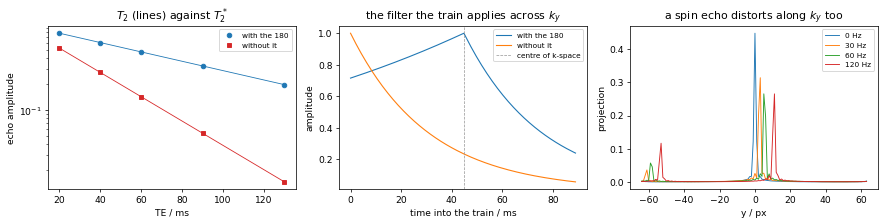

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.5))
axes[0].semilogy(TE_SWEEP * 1e3, envelopes['with the 180'], 'o', ms=5, color='C0',
                 label='with the 180')
axes[0].semilogy(TE_SWEEP * 1e3, envelopes['without it'], 's', ms=5, color='C3',
                 label='without it')
axes[0].semilogy(TE_SWEEP * 1e3, envelopes['with the 180'][0]
                 * np.exp(-(TE_SWEEP - TE_SWEEP[0]) / tissue['t2_s']), '-', lw=0.9, color='C0')
axes[0].semilogy(TE_SWEEP * 1e3, envelopes['without it'][0]
                 * np.exp(-(TE_SWEEP - TE_SWEEP[0]) / t2star_s), '-', lw=0.9, color='C3')
axes[0].set(xlabel='TE / ms', ylabel='echo amplitude', title='$T_2$ (lines) against $T_2^*$')
axes[0].legend(fontsize=8)

axes[1].plot(times * 1e3, se_envelope / se_envelope.max(), lw=1.2, label='with the 180')
axes[1].plot(times * 1e3, gre_envelope / gre_envelope.max(), lw=1.2, label='without it')
axes[1].axvline(centre_echo * esp * 1e3, color='0.6', lw=0.8, ls='--',
                label='centre of k-space')
axes[1].set(xlabel='time into the train / ms', ylabel='amplitude',
            title='the filter the train applies across $k_y$')
axes[1].legend(fontsize=8)

for offset_hz in OFFSETS:
    axes[2].plot(np.arange(NY) - NY // 2, se_images[offset_hz].sum(axis=1)
                 / se_images[offset_hz].sum(), lw=1.0, label=f'{offset_hz:.0f} Hz')
axes[2].set(xlabel='y / px', ylabel='projection', title='a spin echo distorts along $k_y$ too')
axes[2].legend(fontsize=8)
fig.tight_layout()

---
## 4. Partial echo, and POCS

A shorter sampling window is a shorter lobe (Rule 1 is an equality, so `T = 2g + Nτ` falls with
`N`), and a shorter lobe is a shorter train, which is **less distortion** — not only a shorter TE.
That is the argument for partial echo in an EPI, and it is the one that is usually left out.

What it costs is half of `kx`, which has to be put back. POCS is
[`../fse_2d/02`](../fse_2d/02_simulate_and_reconstruct.ipynb)'s implementation, unchanged: the
symmetric centre of k-space gives a phase estimate, and the iteration alternates between
*magnitude from the reconstruction* and *phase from the estimate* while re-imposing the measured
samples.

In [6]:
def pocs(kspace, sampled, *, iterations=12):
    """Fill unsampled kx with POCS: phase from the symmetric centre, magnitude from the iterate."""
    covered = np.flatnonzero(sampled)
    half = min(covered.max() - NX // 2, NX // 2 - covered.min())
    window = np.zeros(NX)
    window[NX // 2 - half:NX // 2 + half + 1] = np.hanning(2 * half + 1)
    phase = np.exp(1j * np.angle(ifft2c(kspace * window[None, :])))
    out = kspace.copy()
    for _ in range(iterations):
        image = ifft2c(out)
        out = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(
            np.abs(image) * phase, axes=(-2, -1)), norm='ortho'), axes=(-2, -1))
        out[:, sampled] = kspace[:, sampled]
    return out


pf_lines = LINES
flags_pf = flags_for(epi_pf, pf_lines)
_, _, covered_pf = regridder_for(epi_pf)

print(f'{"acquisition":22s} {"samples":>8s} {"esp":>7s} {"train":>8s} {"TE":>9s} '
      f'{"predicted":>10s} {"measured":>9s}')
for label, made, name, spacing in (
        ('full echo', epi, 'se_epi_full', esp),
        ('partial echo 0.75', epi_pf, 'se_epi_pf075', float(nominal['echo_spacing_s_pf']))):
    raw = play(name, spin(offset_hz=60.0), made)[:, :, 0]
    image = np.abs(ifft2c(place(regrid(raw, made, flags_for(made, LINES)), LINES)))
    centroid = peak_centroid(image)
    te = TE_S if made is epi else float(nominal['te_s_pf'])
    print(f'{label:22s} {made.num_samples:8d} {spacing * 1e6:6.0f}u '
          f'{NY * spacing * 1e3:7.2f}m {te * 1e3:8.2f}m {60.0 * NY * spacing:9.2f}px '
          f'{centroid:8.2f}px')
print(f'\n{100 * (1 - float(nominal["echo_spacing_s_pf"]) / esp):.0f} % off the echo spacing, so '
      f'{100 * (1 - float(nominal["echo_spacing_s_pf"]) / esp):.0f} % off the train and')
print('the same off the distortion.  The shorter TE is the well-known half of this; the shorter')
print('train is the half that matters for an EPI.')
print(f'\nkx coverage: {covered_pf.sum()} of {NX} grid points are sampled, '
      f'{NX - covered_pf.sum()} are not.')
print('Those are not zeros to be ignored -- they are half of k-space, and POCS is what puts them')
print('back using the fact that a real object has a slowly varying phase.')

acquisition             samples     esp    train        TE  predicted  measured


full echo                   256    700u   89.60m   100.00m      5.38px     5.36px


partial echo 0.75           192    540u   69.12m   100.00m      4.15px     4.20px

23 % off the echo spacing, so 23 % off the train and
the same off the distortion.  The shorter TE is the well-known half of this; the shorter
train is the half that matters for an EPI.

kx coverage: 92 of 128 grid points are sampled, 36 are not.
Those are not zeros to be ignored -- they are half of k-space, and POCS is what puts them
back using the fact that a real object has a slowly varying phase.


---
## 5. A brain: what a shorter train is worth

The three things above, on an object, behind `BRAIN_IMAGES`. The B0 map is the same synthesised
gradient-plus-hot-spot as [`../gre_epi_2d/02`](../gre_epi_2d/02_simulate_and_reconstruct.ipynb)
§6, so the two notebooks' images are directly comparable — which is the point, because the
comparison **is** the measurement in §2.

In [7]:
def brain(field_hz=None):
    """The shared slab, with an optional off-resonance map.  See ``../phantom.py``."""
    return ph.built(matrix=NX, nz=NZ, z_center=Z_CENTER, n_coils=N_COILS, field_hz=field_hz)


def rss(image):
    return np.sqrt((np.abs(image) ** 2).sum(0))


#: The phantom's own B0 map, on the same slab as ``../gre_epi_2d/02`` §6, so the two notebooks'
#: images are directly comparable -- which is the measurement, because §2's whole claim is that a
#: spin echo distorts the same way a gradient echo does.  That notebook says what the map is: it
#: is MRzero's own analytic one, not a measurement, and it needs no shimming because it arrives
#: demeaned over the proton density.
FIELD_HZ = ph.field_hz(matrix=NX, nz=NZ, z_center=Z_CENTER)
BRAIN = ph.mask(matrix=NX, nz=NZ, z_center=Z_CENTER)
inside = FIELD_HZ[BRAIN]

print(f'over the brain {np.percentile(inside, 1):+.0f} to {np.percentile(inside, 99):+.0f} Hz, '
      f'which is {np.percentile(inside, 1) / (1 / (NY * esp)):+.0f} to '
      f'{np.percentile(inside, 99) / (1 / (NY * esp)):+.0f} px along ky')

if BRAIN_IMAGES:
    began = time.perf_counter()
    brain_images = {}
    phantom = brain(FIELD_HZ)

    raw = play('se_epi_full', brain(0.0), epi)
    grid = np.stack([regrid(raw[:, :, c], epi, flags) for c in range(N_COILS)])
    brain_images['full echo, shimmed'] = rss(ifft2c(place(grid, LINES, coils=True)))

    raw = play('se_epi_full', phantom, epi)
    grid = np.stack([regrid(raw[:, :, c], epi, flags) for c in range(N_COILS)])
    brain_images['full echo, real field'] = rss(ifft2c(place(grid, LINES, coils=True)))

    raw = play('se_epi_pf075', phantom, epi_pf)
    grid = np.stack([regrid(raw[:, :, c], epi_pf, flags_pf) for c in range(N_COILS)])
    partial = place(grid, LINES, coils=True)
    brain_images['partial echo, zero filled'] = rss(ifft2c(partial))
    brain_images['partial echo, POCS'] = rss(ifft2c(pocs(partial, covered_pf)))
    print(f'four acquisitions on the slab in {time.perf_counter() - began:.0f} s\n')

    # Signal, not just geometry: the figure below is drawn on one intensity scale, so the dimmer
    # panels are dimmer because they *are*.  Worth quantifying rather than leaving to the eye.
    body = brain_images['full echo, shimmed'] > 0.1 * brain_images['full echo, shimmed'].max()
    baseline = brain_images['full echo, shimmed'][body].sum()
    print(f'{"acquisition":28s} {"signal in the object":>21s}')
    for label, image in brain_images.items():
        print(f'{label:28s} {image[body].sum() / baseline:20.2f}x')
    print('\nOff-resonance along ky is a **displacement**: it moves signal between voxels')
    print('rather than destroying it, so the distorted panels differ from their neighbours in')
    print('geometry and barely at all in brightness.  One intensity scale is what shows that.')
    print(f'\nThe second row keeps '
          f'{brain_images["full echo, real field"][body].sum() / baseline:.2f}x of its signal, and')
    print('../gre_epi_2d/02 section 6 prints the same for a train with **no** refocusing pulse.')
    print('So the 180 shows no advantage here, and the reason is the map: signal is lost only')
    print("where the field varies *within a voxel*, which is what T2' is and what a 180 undoes,")
    print('and two smooth Lorentzians have no gradient that steep.  Section 2 has already shown')
    print('it has no advantage at all over the geometry.')
    print()
    print('The partial-echo rows are worth a glance for what they do *not* show.  Partial echo')
    print('exists to buy a shorter TE -- '
          f'{float(nominal["min_te_s_pf"]) * 1e3:.1f} ms here against '
          f'{float(nominal["min_te_s"]) * 1e3:.1f} -- and at one T2 of echo')
    print(f'time that is worth a great deal.  Held at {TE_S * 1e3:.0f} ms with everything else it '
          f'gives up half')
    print('its readout window and buys nothing back, which is what makes these two panels a')
    print('measurement of the *reconstruction* rather than of the echo time.  `01` section 3')
    print('prices the TE it could have had; section 4 above is what POCS recovers of the window.')
else:
    brain_images = {}
    print('BRAIN_IMAGES is False -- no images, and no numbers lost.')

over the brain -11 to +41 Hz, which is -1 to +4 px along ky


four acquisitions on the slab in 38 s

acquisition                   signal in the object
full echo, shimmed                           1.00x
full echo, real field                        1.00x
partial echo, zero filled                    1.00x
partial echo, POCS                           1.00x

Off-resonance along ky is a **displacement**: it moves signal between voxels
rather than destroying it, so the distorted panels differ from their neighbours in
geometry and barely at all in brightness.  One intensity scale is what shows that.

The second row keeps 1.00x of its signal, and
../gre_epi_2d/02 section 6 prints the same for a train with **no** refocusing pulse.
So the 180 shows no advantage here, and the reason is the map: signal is lost only
where the field varies *within a voxel*, which is what T2' is and what a 180 undoes,
and two smooth Lorentzians have no gradient that steep.  Section 2 has already shown
it has no advantage at all over the geometry.

The partial-echo rows are wort

### Segmentation: the same lines, in two and in four shots

§2 established that a refocusing pulse does not touch EPI distortion, and that only a shorter
train does. [`01`](01_build.ipynb) §3 lists the two ways to get one — accelerate and unfold, or
**segment and interleave** — and takes the second, because a spin-echo TR is already long for
reasons that have nothing to do with EPI.

`se_epi_2shot` and `se_epi_4shot` acquire the **same 128 lines** as `se_epi_full`, at the **same
echo time**, split across interleaved shots. Nothing is under-sampled and nothing is unfolded, so
what falls below is distortion and not a reconstruction residual.

> An interleaved table puts consecutive `ky` lines in **different shots**, so any shot-to-shot
> difference in signal is a modulation of period `S` along `ky` — a replica of the object at
> `Ny/S`. That is what segmentation costs, it looks exactly like an under-sampling artefact, and
> the run-in `01` gives every file is what buys it back. Both columns are below.

In [8]:
if BRAIN_IMAGES:
    began = time.perf_counter()
    TABLES = {s: [[int(v) for v in table] for table in nominal[f'tables_{s}']] for s in SHOTS}
    per_shot, made_for = {}, {1: epi}

    for s in SHOTS[1:]:
        made_for[s] = readout(blip_lines=s)
        raw = play(f'se_epi_{s}shot', phantom, made_for[s])
        grid_s, row, signal = np.zeros((N_COILS, NY, NX), np.complex64), 0, []
        for table in TABLES[s]:
            block = raw[row:row + len(table)]
            row += len(table)
            signal.append(float(np.abs(block[:, :, 0]).mean()))
            grid_s[:, list(table)] = np.stack(
                [regrid(block[:, :, c], made_for[s], flags_for(made_for[s], table))
                 for c in range(N_COILS)])
        brain_images[f'{s} shots'] = rss(ifft2c(grid_s))
        per_shot[s] = np.array(signal)
    print(f'{len(SHOTS) - 1} segmented acquisitions in {time.perf_counter() - began:.0f} s\n')

    # --- what the shorter train buys ------------------------------------------------------
    truth_image = brain_images['full echo, shimmed']
    body = truth_image > 0.1 * truth_image.max()
    worst_hz = float(np.percentile(inside, 99))

    def residual(image):
        """How far this image is from the undistorted one, after one global scale."""
        scale = image[body].sum() / truth_image[body].sum()
        return float(np.abs(image - truth_image * scale).sum() / (truth_image * scale).sum())

    print(f'{"shots":>6s} {"esp":>7s} {"train":>9s} {"predicted shift":>16s} '
          f'{"residual vs shimmed":>20s} {"scan":>6s}')
    for s in SHOTS:
        train = len(TABLES[s][0]) * made_for[s].echo_spacing_s
        label = 'full echo, real field' if s == 1 else f'{s} shots'
        print(f'{s:6d} {made_for[s].echo_spacing_s * 1e6:6.0f}u {train * 1e3:8.2f}m '
              f'{worst_hz * train:13.1f}px {residual(brain_images[label]):20.3f} '
              f'{s * float(nominal["tr_s"]):5.0f}s')
    print()
    print(f'The predicted shift is the 99th-percentile field offset ({worst_hz:.0f} Hz) times the')
    print('train duration, and the residual is what is left against the shimmed image once a')
    print('single global scale is taken out.  They fall together, which is the whole claim: the')
    print('distortion is proportional to the train and nothing else in the sequence touches it.')
    print('Four shots cost four TRs and buy a four-times shorter train -- and unlike an R = 4')
    print('acceleration, there is no calibration band, no kernel and no unfolding residual,')
    print('because every line was actually acquired.')

    # --- and what it costs: the shots have to agree ---------------------------------------
    print(f'\n{"shots":>6s} {"per-shot signal":>34s} {"spread":>8s} {"replica at Ny/S":>16s}')
    for s in SHOTS[1:]:
        image = brain_images[f'{s} shots']
        fold = (~body) & (np.roll(body, NY // s, axis=0) | np.roll(body, -NY // s, axis=0))
        spread = (per_shot[s].max() - per_shot[s].min()) / per_shot[s].mean()
        print(f'{s:6d} {str([round(float(v), 2) for v in per_shot[s]]):>34s} {spread:7.1%} '
              f'{image[fold].mean() / image[body].mean():16.4f}')
    print()
    print('The per-shot column is not flat and is not meant to be: each shot samples a different')
    print('subset of ky, and the one holding k = 0 carries more signal than the others whatever')
    print('the magnetisation is doing.  What would matter is a difference the *steady state* put')
    print('there, and the run-in is what removes that -- ../gre_epi_2d/02 section 8 decomposes it')
    print('over three files and measures 9.6x between the ends.  Here it is already paid for.')

2 segmented acquisitions in 27 s

 shots     esp     train  predicted shift  residual vs shimmed   scan
     1    700u    89.60m           3.6px                0.127     1s
     2    720u    46.08m           1.9px                0.073     2s
     4    740u    23.68m           1.0px                0.047     4s

The predicted shift is the 99th-percentile field offset (41 Hz) times the
train duration, and the residual is what is left against the shimmed image once a
single global scale is taken out.  They fall together, which is the whole claim: the
distortion is proportional to the train and nothing else in the sequence touches it.
Four shots cost four TRs and buy a four-times shorter train -- and unlike an R = 4
acceleration, there is no calibration band, no kernel and no unfolding residual,
because every line was actually acquired.

 shots                    per-shot signal   spread  replica at Ny/S
     2                        [2.1, 1.99]    5.8%           0.0210
     4            [2

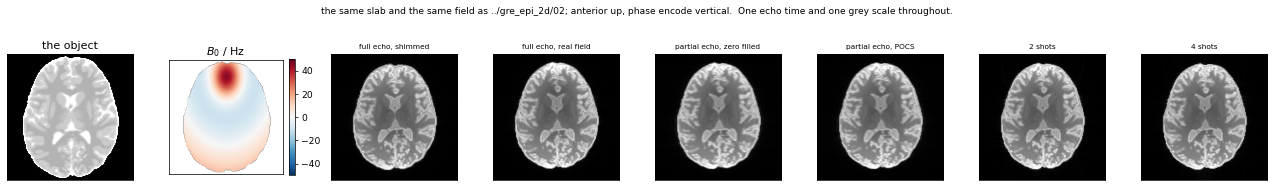

In [9]:
if brain_images:
    truth = ph.volume(matrix=NX).PD.numpy()[..., ph.slices_of(NZ, Z_CENTER)][:, :, NZ // 2]
    fig, axes = plt.subplots(1, len(brain_images) + 2,
                             figsize=(2.4 * len(brain_images) + 5.0, 3.2))
    axes[0].imshow(ph.same_frame(truth), cmap='gray', origin='lower')
    axes[0].set(title='the object')
    field = axes[1].imshow(ph.same_frame(np.where(BRAIN, FIELD_HZ, np.nan)[:, :, NZ // 2]),
                           cmap='RdBu_r', vmin=-50, vmax=50, origin='lower')
    axes[1].set(title='$B_0$ / Hz')
    plt.colorbar(field, ax=axes[1], fraction=0.046)
    # One intensity scale across every panel.  Letting each autoscale is what makes a figure of
    # this kind lie: the distorted acquisitions pile signal into a few bright pixels, so their own
    # maxima are higher and the *brain* in them is drawn darker than the brain beside it.
    # **One scale across the whole figure**, which holding TE is what buys: every file here is at
    # 100 ms, the same flip and the same TR, behind the same run-in, so the panels differ by their
    # acquisition alone.  At one T2 of echo time a contrast difference between two of them would
    # dwarf everything the acquisition does, and sharing a ceiling across panels that did not
    # share a contrast is the version of this figure that lies.
    ceiling = max(float(np.percentile(image, 99.5)) for image in brain_images.values())
    ceilings = {label: ceiling for label in brain_images}
    for ax, (label, image) in zip(axes[2:], brain_images.items()):
        ax.imshow(image, cmap='gray', vmin=0.0, vmax=ceilings[label], origin='lower')
        ax.set_title(label, fontsize=8)
    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])
    fig.suptitle('the same slab and the same field as ../gre_epi_2d/02; anterior up, phase '
                 'encode vertical.  One echo time and one grey scale throughout.', fontsize=10)
    fig.tight_layout()

---
## What this notebook measured

| | |
|---|---|
| **it is a spin echo** | the train recovers the phantom's T2 and the same probe without the 180 recovers T2\*, which is the one claim `01`'s arithmetic could not make |
| **a spin echo does not fix EPI distortion** | same shift, same prediction, same ghost as the gradient echo at the same echo spacing. The pulse refocuses at *one instant*; the distortion is accumulated *between* echoes |
| **what it does fix is the envelope** | the T2 filter across `ky` peaks at the centre of k-space instead of decaying from the start: **4.3× the signal** on the lines that carry the contrast, and half the excess point-spread width against a flat-envelope floor. Both measured, and the floor is in the table because without it neither claim could be sized |
| **partial echo shortens the train, not only the TE** | which is the half of the argument usually left out, and POCS puts the missing `kx` back |
| **only a shorter train touches the distortion** | four interleaved shots cut the train four-fold and the residual against the shimmed image falls with it. Segmenting buys the same short train an `R = 4` acceleration would, at four TRs and with **no** calibration band, kernel or unfolding residual — which is affordable precisely because a spin-echo TR is already long |
| **every panel is at one echo time** | 100 ms, checked in `01` and printed. At one T2 of TE a contrast difference between two panels would dwarf anything the acquisition does, so holding TE is what makes §5 a measurement rather than an illustration |

**The thing to take away** is the second row. It is the reason an EPI is shimmed, field-mapped and
segmented rather than refocused, and it is not what the phrase "spin-echo EPI" suggests.